**Machine A October**

In [ ]:
# Import Libraries
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

# Load Dataset
from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]

# Read CSV
df = pd.read_csv(filename, encoding='latin1')
df.head()

Saving MACHINE_A_OCTOBER_FINAL.csv to MACHINE_A_OCTOBER_FINAL.csv


,Group Name,Machine,Transaction Date,Transaction No,Slot No,Product Code,Menu,Service,Status,Delivery,Categories,Price
0,Master,Machine A,31-10-25 20:34,3216039,31,UMMIS3,Chicken & Yuzu Poke Bowl,Cash,Successful,Delivery,Non vegetarian,Standard
1,Master,Machine A,31-10-25 20:16,3215947,21,UMMIS17,Chicken Brown & Wild Rice Salad,Cash,Successful,Delivery,Non vegetarian,Standard
2,Master,Machine A,31-10-25 19:42,3215444,17,UMMIF1,Banana Berry Acai Bowl,Cash,Successful,Delivery,Gluten-free,Affordable
3,Master,Machine A,31-10-25 19:40,3215387,11,UMMIV10,Fajita Chicken Wrap,Cash,Successful,Delivery,Non vegetarian,Standard
4,Master,Machine A,31-10-25 19:40,3215231,61,UMMIS7,Pumpkin & Beetroot Salad with Orange Vinaigrette,Cash,Successful,Delivery,Vegetarian,Standard


In [ ]:
# Cleaning Column Names
df.columns = df.columns.str.strip()

In [ ]:
# Preprocessing

# Standardize column names
df.columns = df.columns.str.strip()

# Drop duplicates
df = df.drop_duplicates()

# Drop rows missing timestamp or menu name
df = df.dropna(subset=["Transaction Date", "Menu"])

# Convert timestamp safely
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")

# Remove rows where timestamp conversion failed
df = df.dropna(subset=["Transaction Date"])


In [ ]:
# FeatureEngineering

# Extract hour as float
df["Hour"] = df["Transaction Date"].dt.hour + df["Transaction Date"].dt.minute / 60

# Remove invalid hours
df = df[(df["Hour"] >= 0) & (df["Hour"] <= 24)]

# Clean menu names
df["Menu"] = df["Menu"].astype(str).str.strip()

# Label meal periods
def label_period(h):
    if 6 <= h < 11:
        return "breakfast"
    elif 11 <= h < 15:
        return "lunch"
    else:
        return "dinner"

df["Period"] = df["Hour"].apply(label_period)


In [ ]:
# Defining Features
X = df[["Hour"]]
y = df["Period"]

In [ ]:
# Training the Model
from sklearn.neighbors import KNeighborsClassifier

K = 7
knn = KNeighborsClassifier(n_neighbors=K)
knn.fit(X, y)

print(f"KNN Model Trained (K={K})")

KNN Model Trained (K=7)


In [ ]:
# Generating Recommendations
def recommend(period_name, query_hour):
    _, indices = knn.kneighbors([[query_hour]])
    neighbors = df.iloc[indices[0]]
    top = neighbors["Menu"].value_counts().head(5)

    print(f"\nTop Items for {period_name} ({query_hour}h)")
    print("-" * 40)
    for item, count in top.items():
        print(f"{item:<40} {count}x")

recommend("Breakfast", 8.5)
recommend("Lunch", 12.5)
recommend("Dinner", 18.5)


Top Items for Breakfast (8.5h)
----------------------------------------
Chicken & Yuzu Poke Bowl                 2x
Banana Berry Acai Bowl                   1x
Coconut Water                            1x
Egg Mayo Sandwich with Brown Bread       1x
Apple Green Juice Fresh                  1x

Top Items for Lunch (12.5h)
----------------------------------------
Chicken Caesar Wrap                      2x
Grilled Chicken Burrito Bowl             1x
Fruit Salad                              1x
Prawn Mango Salad                        1x
Chicken Brown & Wild Rice Salad          1x

Top Items for Dinner (18.5h)
----------------------------------------
Mixed Berry Smoothie                     1x
Chicken Tikka Club with Brown Bread      1x
Creamy Chicken Pesto with Chunky Red Rice 1x
Banana Berry Acai Bowl                   1x
Watermelon Juice Fresh                   1x


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


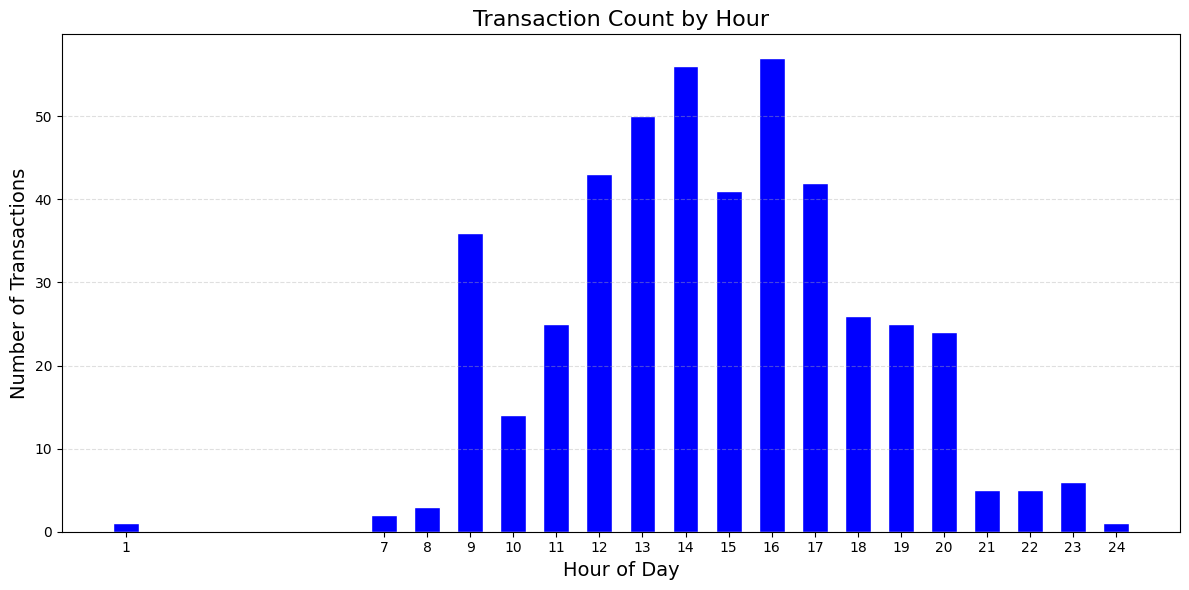

In [ ]:
# Distribution of Transactions by Hour

import matplotlib.pyplot as plt

# Count transactions per hour
hour_counts = df["Hour"].round().value_counts().sort_index()

plt.figure(figsize=(12,6))
plt.bar(hour_counts.index, hour_counts.values,
        color="blue", edgecolor="white", width=0.6)

plt.title("Transaction Count by Hour", fontsize=16)
plt.xlabel("Hour of Day", fontsize=14)
plt.ylabel("Number of Transactions", fontsize=14)

plt.xticks(hour_counts.index)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


**Machine B October**

In [ ]:
# Import Libraries
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

# Load Dataset
from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]

# Read CSV
df = pd.read_csv(filename, encoding='latin1')
df.head()

Saving MACHINE_B_OCTOBER_FINAL.csv to MACHINE_B_OCTOBER_FINAL.csv


,ï»¿Group Name,Machine,Transaction Date,Transaction No,Slot No,Product Code,Menu,Service,Status,Delivery,Category,Price
0,Master,Machine B,2025-10-31 07:51:50,3216354,3,UMMIM1,Mixed Berry Smoothie,Cash,Successful,Delivery,Beverage,Affordable
1,Master,Machine B,2025-10-31 05:31:24,3214755,2,UMMIJ5,Watermelon Juice Fresh,Cash,Successful,Delivery,Beverage,Affordable
2,Master,Machine B,2025-10-31 16:14:09,3211802,2,UMMIJ5,Watermelon Juice Fresh,Cash,Successful,Delivery,Beverage,Affordable
3,Master,Machine B,2025-10-31 15:33:35,3210031,3,UMMIM1,Mixed Berry Smoothie,Cash,Successful,Delivery,Beverage,Affordable
4,Master,Machine B,2025-10-31 01:10:43,3208401,31,UMMIR14,Herb Mushroom Chicken With Farfalle Pesto,Cash,Successful,Delivery,Non vegetarian,Premium


In [ ]:
# Cleaning Column Names
df.columns = df.columns.str.strip()

In [ ]:
# Preprocessing

# Standardize column names
df.columns = df.columns.str.strip()

# Drop duplicates
df = df.drop_duplicates()

# Drop rows missing timestamp or menu name
df = df.dropna(subset=["Transaction Date", "Menu"])

# Convert timestamp safely
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")

# Remove rows where timestamp conversion failed
df = df.dropna(subset=["Transaction Date"])

In [ ]:
# FeatureEngineering

# Extract hour as float
df["Hour"] = df["Transaction Date"].dt.hour + df["Transaction Date"].dt.minute / 60

# Remove invalid hours
df = df[(df["Hour"] >= 0) & (df["Hour"] <= 24)]

# Clean menu names
df["Menu"] = df["Menu"].astype(str).str.strip()

# Label meal periods
def label_period(h):
    if 6 <= h < 11:
        return "breakfast"
    elif 11 <= h < 15:
        return "lunch"
    else:
        return "dinner"

df["Period"] = df["Hour"].apply(label_period)

In [ ]:
# Defining Features
X = df[["Hour"]]
y = df["Period"]

In [ ]:
# Training the Model
from sklearn.neighbors import KNeighborsClassifier

K = 7
knn = KNeighborsClassifier(n_neighbors=K)
knn.fit(X, y)

print(f"KNN Model Trained (K={K})")

KNN Model Trained (K=7)


In [ ]:
# Generating Recommendations
def recommend(period_name, query_hour):
    _, indices = knn.kneighbors([[query_hour]])
    neighbors = df.iloc[indices[0]]
    top = neighbors["Menu"].value_counts().head(5)

    print(f"\nTop Items for {period_name} ({query_hour}h)")
    print("-" * 40)
    for item, count in top.items():
        print(f"{item:<40} {count}x")

recommend("Breakfast", 8.5)
recommend("Lunch", 12.5)
recommend("Dinner", 18.5)


Top Items for Breakfast (8.5h)
----------------------------------------
Chicken Tikka Club with Brown Bread      2x
Dynamite Chicken Sandwich on Brown Bread 1x
Chicken & Yuzu Poke Bowl                 1x
Chicken Tandoori with Coriander Rice     1x
Chicken Brown & Wild Rice Salad          1x

Top Items for Lunch (12.5h)
----------------------------------------
Falafel Wrap                             2x
Chicken Tandoori with Basil Rice         1x
Mixed Berry Smoothie                     1x
Prawn Mango Salad                        1x
Steamed Rice with Butter Chicken         1x

Top Items for Dinner (18.5h)
----------------------------------------
Chicken Brown & Wild Rice Salad          2x
Watermelon Juice Fresh                   1x
Chicken Tandoori with Basil Rice         1x
Pomegranate Juice                        1x
Herb Mushroom Chicken With Farfalle Pesto 1x


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


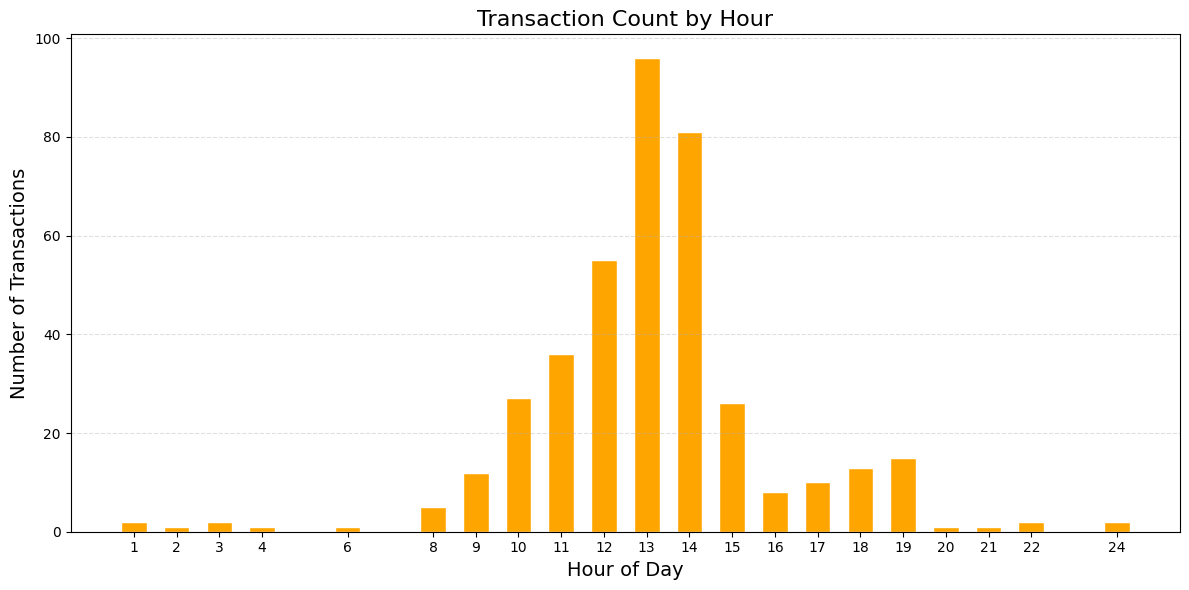

In [ ]:
# Distribution of Transactions by Hour

import matplotlib.pyplot as plt

# Count transactions per hour
hour_counts = df["Hour"].round().value_counts().sort_index()

plt.figure(figsize=(12,6))
plt.bar(hour_counts.index, hour_counts.values,
        color="orange", edgecolor="white", width=0.6)

plt.title("Transaction Count by Hour", fontsize=16)
plt.xlabel("Hour of Day", fontsize=14)
plt.ylabel("Number of Transactions", fontsize=14)

plt.xticks(hour_counts.index)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

**Machine A November**

In [ ]:
# Import Libraries
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

# Load Dataset
from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]

# Read CSV
df = pd.read_csv(filename, encoding='latin1')
df.head()

Saving MACHINE_A_NOVEMBER_FINAL.csv to MACHINE_A_NOVEMBER_FINAL.csv


,Group Name,Machine,Transaction Date,Transaction No,Slot No,Product Code,Product Name,Service,Status,Delivery,Category,Price
0,Master,Machine A,28-11-25 17:04,3995547,31,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium
1,Master,Machine A,28-11-25 14:10,3992640,31,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium
2,Master,Machine A,28-11-25 13:32,3991769,37,UMMIR10,Creamy Chicken Pesto with Chunky Red Rice,Cash,Successful,Delivery,Non vegetarian,Premium
3,Master,Machine A,28-11-25 13:17,3990658,17,UMMIR13,Spicy Chicken with Pearl CousCous,Cash,Successful,Delivery,Non vegetarian,Standard
4,Master,Machine A,28-11-25 12:36,3988280,51,UMMIS5,Mixed Beans & CousCous Salad,Cash,Successful,Delivery,Vegetarian,Standard


In [ ]:
# Cleaning Column Names
df.columns = df.columns.str.strip()

# Rename Product Name → Menu (only if it exists)
if "Product Name" in df.columns:
    df.rename(columns={"Product Name": "Menu"}, inplace=True)


In [ ]:
# Preprocessing

# Standardize column names
df.columns = df.columns.str.strip()

# Drop duplicates
df = df.drop_duplicates()

# Drop rows missing timestamp or menu name
df = df.dropna(subset=["Transaction Date", "Menu"])

# Convert timestamp safely
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")

# Remove rows where timestamp conversion failed
df = df.dropna(subset=["Transaction Date"])


In [ ]:
# FeatureEngineering

# Extract hour as float
df["Hour"] = df["Transaction Date"].dt.hour + df["Transaction Date"].dt.minute / 60

# Remove invalid hours
df = df[(df["Hour"] >= 0) & (df["Hour"] <= 24)]

# Clean menu names
df["Menu"] = df["Menu"].astype(str).str.strip()

# Label meal periods
def label_period(h):
    if 6 <= h < 11:
        return "breakfast"
    elif 11 <= h < 15:
        return "lunch"
    else:
        return "dinner"

df["Period"] = df["Hour"].apply(label_period)


In [ ]:
# Defining Features
X = df[["Hour"]]
y = df["Period"]

In [ ]:
# Training the Model
from sklearn.neighbors import KNeighborsClassifier

K = 7
knn = KNeighborsClassifier(n_neighbors=K)
knn.fit(X, y)

print(f"KNN Model Trained (K={K})")

KNN Model Trained (K=7)


In [ ]:
# Generating Recommendations
def recommend(period_name, query_hour):
    _, indices = knn.kneighbors([[query_hour]])
    neighbors = df.iloc[indices[0]]
    top = neighbors["Menu"].value_counts().head(5)

    print(f"\nTop Items for {period_name} ({query_hour}h)")
    print("-" * 40)
    for item, count in top.items():
        print(f"{item:<40} {count}x")

recommend("Breakfast", 8.5)
recommend("Lunch", 12.5)
recommend("Dinner", 18.5)


Top Items for Breakfast (8.5h)
----------------------------------------
Chicken Caesar Wrap                      2x
Avo-licious Pot                          1x
Pasta & Herb Chicken Salad               1x
Mango Berry Cacao Bowl                   1x
Banana Berry Acai Bowl                   1x

Top Items for Lunch (12.5h)
----------------------------------------
Mango Berry Cacao Bowl                   2x
Orange Juice Fresh                       1x
Coconut Punch Cold Pressed Juice         1x
Pasta & Herb Chicken Salad               1x
Mixed Beans & CousCous Salad             1x

Top Items for Dinner (18.5h)
----------------------------------------
Spicy Chicken with Pearl CousCous        1x
Rajma Curry with White Rice              1x
Chicken Biryani                          1x
Grilled Chicken Burrito Bowl             1x
Mango Smoothie                           1x


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


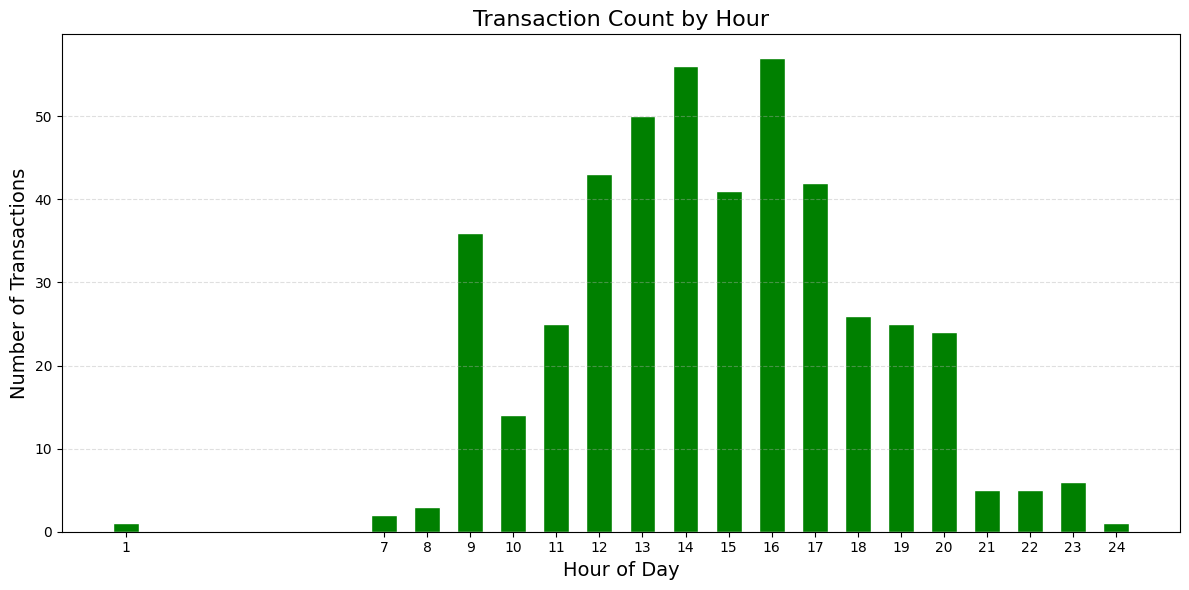

In [ ]:
# Distribution of Transactions by Hour

import matplotlib.pyplot as plt

# Count transactions per hour
hour_counts = df["Hour"].round().value_counts().sort_index()

plt.figure(figsize=(12,6))
plt.bar(hour_counts.index, hour_counts.values,
        color="green", edgecolor="white", width=0.6)

plt.title("Transaction Count by Hour", fontsize=16)
plt.xlabel("Hour of Day", fontsize=14)
plt.ylabel("Number of Transactions", fontsize=14)

plt.xticks(hour_counts.index)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


**Machine B November**

In [ ]:
# Import Libraries
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

# Load Dataset
from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]

# Read CSV
df = pd.read_csv(filename, encoding='latin1')
df.head()

Saving MACHINE_B_NOVEMBER_FINAL.csv to MACHINE_B_NOVEMBER_FINAL (10).csv


,ï»¿Group Name,Machine,Transaction Date,Transaction No,Slot No,Product Code,Menu,Service,Status,Delivery,Category,Price
0,Master,Machine B,28-11-25 13:06,3990009,37,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium
1,Master,Machine B,28-11-25 13:03,3989850,11,UMMIG1,Grilled Chicken Burrito Bowl,Cash,Successful,Delivery,Non vegetarian,Premium
2,Master,Machine B,28-11-25 09:25,3985694,27,UMMIR7,Sweet And Sour Prawn Teriyaki Noodles,Cash,Successful,Delivery,Non vegetarian,Premium
3,Master,Machine B,27-11-25 16:45,3983556,37,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium
4,Master,Machine B,27-11-25 14:42,3980068,34,UMMIR10,Creamy Chicken Pesto with Chunky Red Rice,Cash,Successful,Delivery,Non vegetarian,Premium


In [ ]:
# Cleaning Column Names
df.columns = df.columns.str.strip()

# Rename Product Name → Menu (only if it exists)
if "Product Name" in df.columns:
    df.rename(columns={"Product Name": "Menu"}, inplace=True)

In [ ]:
# Preprocessing

# Standardize column names
df.columns = df.columns.str.strip()

# Drop duplicates
df = df.drop_duplicates()

# Drop rows missing timestamp or menu name
df = df.dropna(subset=["Transaction Date", "Menu"])

# Convert timestamp safely
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")

# Remove rows where timestamp conversion failed
df = df.dropna(subset=["Transaction Date"])

/tmp/ipykernel_266/1059526916.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")


In [ ]:
# FeatureEngineering

# Extract hour as float
df["Hour"] = df["Transaction Date"].dt.hour + df["Transaction Date"].dt.minute / 60

# Remove invalid hours
df = df[(df["Hour"] >= 0) & (df["Hour"] <= 24)]

# Clean menu names
df["Menu"] = df["Menu"].astype(str).str.strip()

# Label meal periods
def label_period(h):
    if 6 <= h < 11:
        return "breakfast"
    elif 11 <= h < 15:
        return "lunch"
    else:
        return "dinner"

df["Period"] = df["Hour"].apply(label_period)

In [ ]:
# Defining Features
X = df[["Hour"]]
y = df["Period"]

In [ ]:
# Training the Model
from sklearn.neighbors import KNeighborsClassifier

K = 7
knn = KNeighborsClassifier(n_neighbors=K)
knn.fit(X, y)

print(f"KNN Model Trained (K={K})")

KNN Model Trained (K=7)


In [ ]:
# Generating Recommendations
def recommend(period_name, query_hour):
    _, indices = knn.kneighbors([[query_hour]])
    neighbors = df.iloc[indices[0]]
    top = neighbors["Menu"].value_counts().head(5)

    print(f"\nTop Items for {period_name} ({query_hour}h)")
    print("-" * 40)
    for item, count in top.items():
        print(f"{item:<40} {count}x")

recommend("Breakfast", 8.5)
recommend("Lunch", 12.5)
recommend("Dinner", 18.5)


Top Items for Breakfast (8.5h)
----------------------------------------
Chicken Caesar Wrap                      3x
Grilled Chicken Burrito Bowl             1x
Coconut Punch Cold Pressed Juice         1x
Egg Mayo Sandwich with Brown Bread       1x
Peanut Butter Strawberry Pot             1x

Top Items for Lunch (12.5h)
----------------------------------------
Grilled Chicken Burrito Bowl             3x
Pomegranate Juice                        2x
BBQ Prawns with Fusilli Pasta            1x
Sweet And Sour Prawn Teriyaki Noodles    1x

Top Items for Dinner (18.5h)
----------------------------------------
Watermelon Marbles                       2x
Purple Power Pot                         1x
Chicken Tikka Club with Brown Bread      1x
Mango Tango Pot                          1x
Avo-licious Pot                          1x


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


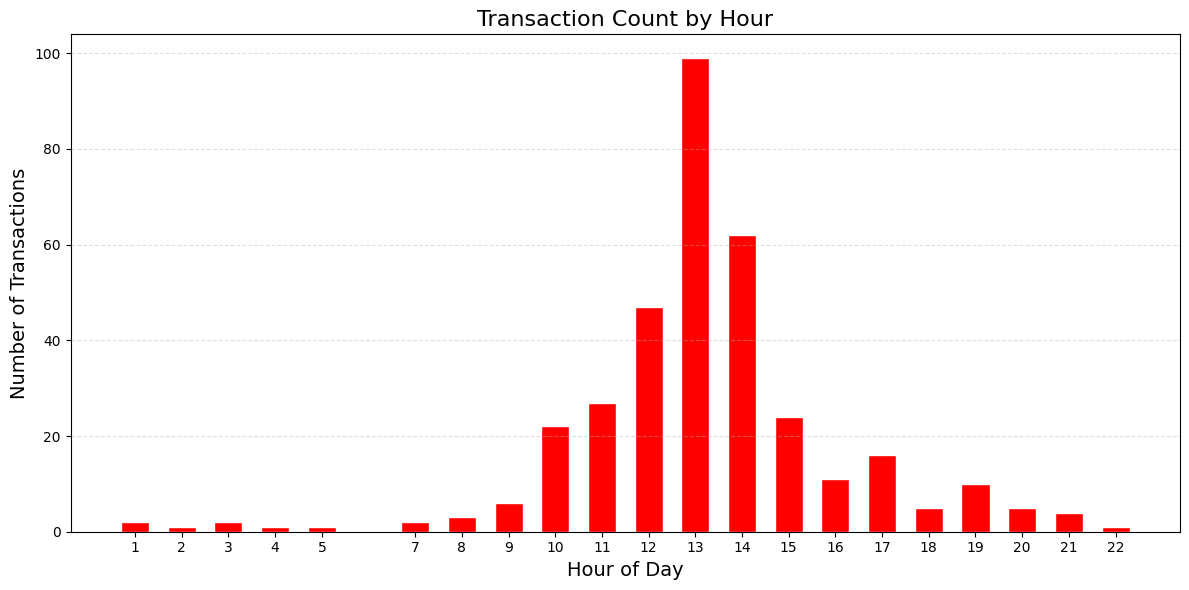

In [ ]:
# Distribution of Transactions by Hour

import matplotlib.pyplot as plt

# Count transactions per hour
hour_counts = df["Hour"].round().value_counts().sort_index()

plt.figure(figsize=(12,6))
plt.bar(hour_counts.index, hour_counts.values,
        color="red", edgecolor="white", width=0.6)

plt.title("Transaction Count by Hour", fontsize=16)
plt.xlabel("Hour of Day", fontsize=14)
plt.ylabel("Number of Transactions", fontsize=14)

plt.xticks(hour_counts.index)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()